## インデックスETFの分析を行う：

In [4]:
import pandas as pd
import yfinance as yf 
import numpy as np 
import matplotlib.pyplot as plt
import datetime
import seaborn as sns 
from kazustat import YFinanceAnalysis
import warnings 
from sklearn.preprocessing import StandardScaler

In [5]:
 # loading: 

growthetf = yf.download("2516.T", start="2020-01-01", end="2026-12-31")
dat = yf.Ticker("2516.T")

[*********************100%***********************]  1 of 1 completed


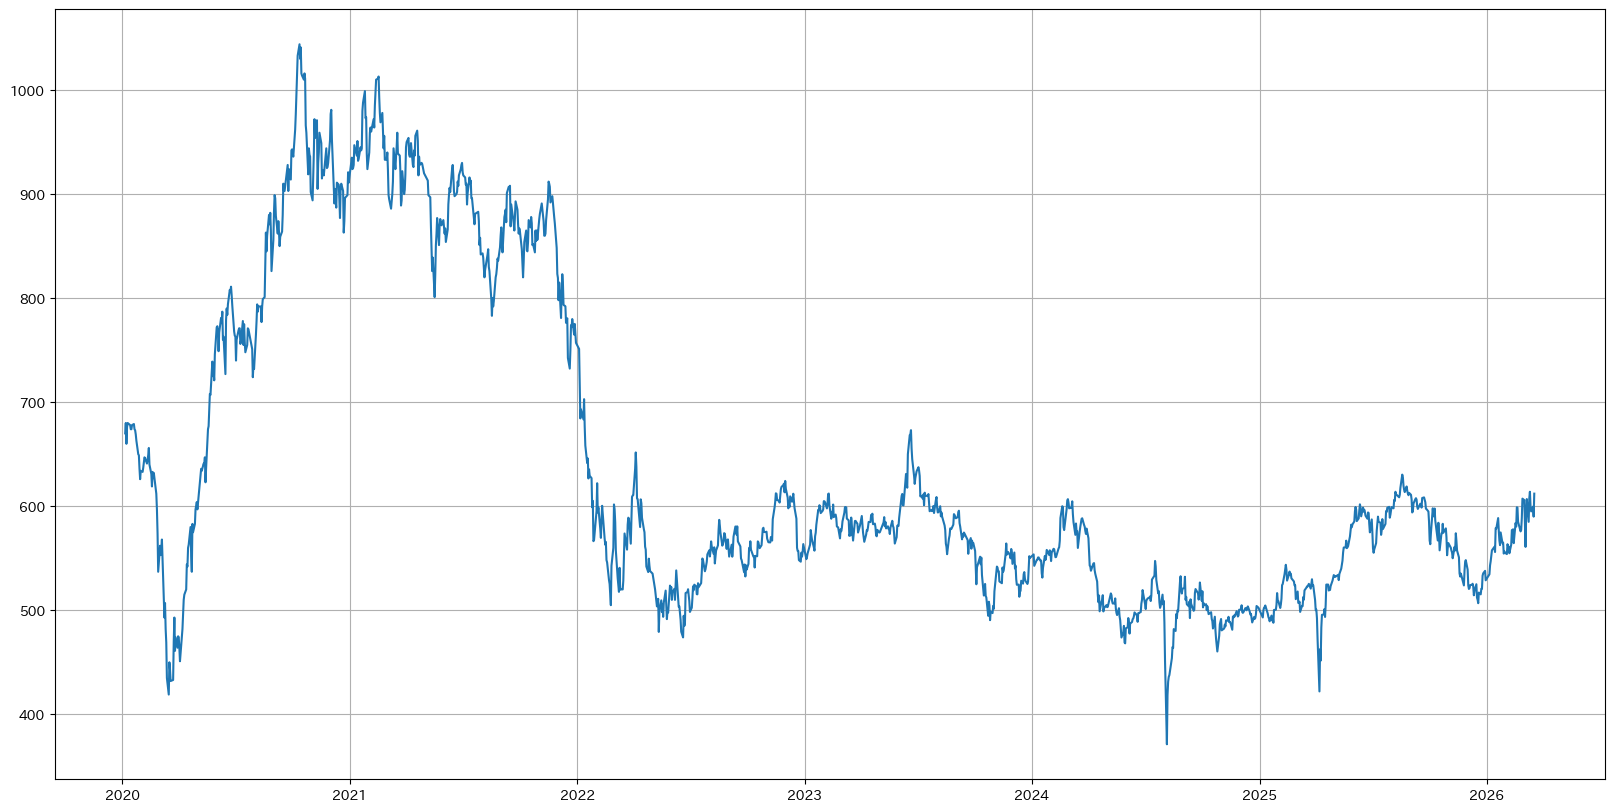

In [6]:
sf = growthetf.reset_index().copy()
sf.columns = ['Date', "Close_SB", "High_SB", "Low_SB", "Open_SB", "Volume_SB"]
plt.figure(figsize=(20,10))
plt.plot(sf['Date'],sf["Close_SB"], label="Growth ETF Close Price")
plt.grid()
plt.show()

[**********************60%****                   ]  3 of 5 completed$^TPX: possibly delisted; no price data found  (period=2y)
[*********************100%***********************]  5 of 5 completed

1 Failed download:
['^TPX']: possibly delisted; no price data found  (period=2y)


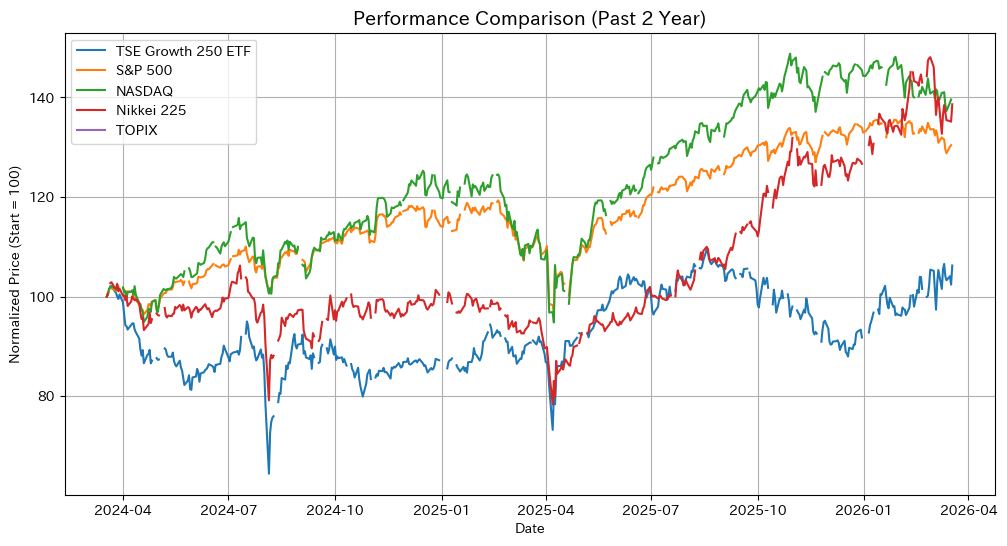

--- Correlation Matrix ---
Ticker              TSE Growth 250 ETF   S&P 500    NASDAQ  Nikkei 225  TOPIX
Ticker                                                                       
TSE Growth 250 ETF            1.000000  0.585431  0.586598    0.504054    NaN
S&P 500                       0.585431  1.000000  0.993396    0.842068    NaN
NASDAQ                        0.586598  0.993396  1.000000    0.847087    NaN
Nikkei 225                    0.504054  0.842068  0.847087    1.000000    NaN
TOPIX                              NaN       NaN       NaN         NaN    NaN


In [7]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. 取得したいティッカーのリスト
tickers = {
    "^N225": "Nikkei 225",
    "^TPX": "TOPIX",
    "2516.T": "TSE Growth 250 ETF",
    "^IXIC": "NASDAQ",
    "^GSPC": "S&P 500"
}

# 2. データのダウンロード (直近1年間)
data = yf.download(list(tickers.keys()), period="2y")["Close"]

# 3. カラム名を分かりやすく変更
data.rename(columns=tickers, inplace=True)

# 4. 分析：開始時点を100として正規化（パフォーマンス比較）
normalized_data = (data / data.iloc[0]) * 100

# 5. 可視化
plt.figure(figsize=(12, 6))
for column in normalized_data.columns:
    plt.plot(normalized_data.index, normalized_data[column], label=column)

plt.title("Performance Comparison (Past 2 Year)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Normalized Price (Start = 100)")
plt.legend()
plt.grid(True)
plt.show()

# 6. 相関関係の確認
print("--- Correlation Matrix ---")
print(data.corr())

In [8]:
dat.info


{'companyOfficers': [],
 'executiveTeam': [],
 'maxAge': 86400,
 'priceHint': 2,
 'previousClose': 590.0,
 'open': 592.0,
 'dayLow': 592.0,
 'dayHigh': 612.3,
 'regularMarketPreviousClose': 590.0,
 'regularMarketOpen': 592.0,
 'regularMarketDayLow': 592.0,
 'regularMarketDayHigh': 612.3,
 'trailingPE': 21.072626,
 'volume': 618340,
 'regularMarketVolume': 618340,
 'averageVolume': 912601,
 'averageVolume10days': 894924,
 'averageDailyVolume10Day': 894924,
 'bid': 612.0,
 'ask': 612.2,
 'bidSize': 0,
 'askSize': 0,
 'yield': 0.0,
 'totalAssets': 12017999872,
 'fiftyTwoWeekLow': 416.4,
 'fiftyTwoWeekHigh': 632.0,
 'allTimeHigh': 1049.0,
 'allTimeLow': 371.2,
 'fiftyDayAverage': 576.586,
 'twoHundredDayAverage': 574.9885,
 'trailingAnnualDividendRate': 0.0,
 'trailingAnnualDividendYield': 0.0,
 'navPrice': 605.0,
 'currency': 'JPY',
 'tradeable': False,
 'ytdReturn': 15.14019,
 'beta3Year': 1.13,
 'fundFamily': 'Simplex Asset Management',
 'fundInceptionDate': 1517356800,
 'legalType': 'E

In [9]:
spy = yf.Ticker('2516.T').funds_data
spy.description
spy.top_holdings

,Name,Holding Percent
Symbol,,
141A.T,Trial Holdings Inc,0.051784
2160.T,GNI Group Ltd,0.047467
4592.T,SanBio Co Ltd,0.036966
485A.T,PowerX Inc,0.023835
186A.T,Astroscale Holdings Inc,0.023489
290A.T,Synspective Inc,0.023186
7777.T,3-D Matrix Ltd,0.021022
4588.T,Oncolys BioPharma Inc,0.020378
7806.T,MTG Co Ltd Ordinary Shares,0.017314


## 単純に時系列モデル試してみるか